## Projeto do Bootcamp Avanti - Machine Learning

🔹 Projeto 03

📌 Assunto: Classificação de lesões em folhas de feijão

🔗 Dataset: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification

📌 Link do Projeto: https://github.com/jaimejrs/avanti-bean-leaf-classification


### Participantes:
Cristiane Santos da Cunha

Eric Gabriel Aguiar de Alencar

Fabrício Almeida Santos

Ian Silva Nogueira

Jaime Teixeira de Araújo Júnior

Juliana Gonçalves Câmara

### ATIVIDADE-04-ETAPA-01
#### Objetivo: Apresentar informações do dataset





#### Baixar dataset do Kaggle

In [1]:
!pip install opendatasets
!pip install pandas
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.4 MB/s eta 0:00:00


In [2]:
import opendatasets as od
import pandas as pd

dataset_path = od.download("https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification")



Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: eng.criscunha
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/marquis03/bean-leaf-lesions-classification


100%|██████████| 155M/155M [00:02<00:00, 74.8MB/s]


In [3]:
# IMPORTAÇÕES
!pip install opencv-python

import pandas as pd
import os
import cv2
import imagehash
import matplotlib.pyplot as plt
%matplotlib inline
import random
import shutil

In [4]:
!ls

bean-leaf-lesions-classification  sample_data


### Criar um Dataframe com os metadados das imagens

In [5]:
root_dir = './bean-leaf-lesions-classification'

#### Separação das imagens para treinamento, teste e validação


In [6]:
# estrutura do data set

print(os.listdir("./bean-leaf-lesions-classification"))

['val.csv', 'train.csv', 'train', 'val', 'classname.txt']


In [7]:
# Criação da pasta teste
train_dir = "./bean-leaf-lesions-classification/train"
test_dir = "./bean-leaf-lesions-classification/test"
os.makedirs(test_dir, exist_ok=True)

In [8]:
# Divisão das imagens entre treinamento e 15% para teste

NUM_TESTE = 154

# -------------------------------------------------------------------
# 1. Devolve todas as imagens de TESTE para TREINAMENTO
# -------------------------------------------------------------------

for classe in os.listdir(test_dir):

    pasta_test = os.path.join(test_dir, classe)
    pasta_train = os.path.join(train_dir, classe)

    if not os.path.isdir(pasta_test):
        continue

    os.makedirs(pasta_train, exist_ok=True)

    for imagem in os.listdir(pasta_test):

        origem = os.path.join(pasta_test, imagem)
        destino = os.path.join(pasta_train, imagem)

        shutil.move(origem, destino)

# -------------------------------------------------------------------
# 2. Lista todas as imagens do treinamento
# -------------------------------------------------------------------

todas_imagens = []

for classe in os.listdir(train_dir):

    pasta_train = os.path.join(train_dir, classe)

    if not os.path.isdir(pasta_train):
        continue

    for imagem in os.listdir(pasta_train):

        todas_imagens.append((classe, imagem))

# -------------------------------------------------------------------
# 3. Sorteia 154 imagens
# -------------------------------------------------------------------

imagens_teste = random.sample(todas_imagens, NUM_TESTE)

# -------------------------------------------------------------------
# 4. Move somente as 154 imagens sorteadas para TESTE
# -------------------------------------------------------------------

for classe, imagem in imagens_teste:

    origem = os.path.join(train_dir, classe, imagem)

    pasta_test = os.path.join(test_dir, classe)
    os.makedirs(pasta_test, exist_ok=True)

    destino = os.path.join(pasta_test, imagem)

    shutil.move(origem, destino)

print(f"{NUM_TESTE} imagens movidas para TESTE com sucesso.")

154 imagens movidas para TESTE com sucesso.


In [9]:
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

train_df.head()

,image:FILE,category
0,train/healthy/healthy_train.98.jpg,0
1,train/healthy/healthy_train.148.jpg,0
2,train/healthy/healthy_train.306.jpg,0
3,train/healthy/healthy_train.305.jpg,0
4,train/healthy/healthy_train.40.jpg,0


In [10]:
print(train_df.columns)

Index(['image:FILE', 'category'], dtype='object')


In [11]:
# Validação

val_df = pd.read_csv("./bean-leaf-lesions-classification/val.csv")

imagens_csv = set(val_df["image:FILE"])
imagens_pasta = set()

val_dir = "./bean-leaf-lesions-classification/val"

for classe in os.listdir(val_dir):
    pasta = os.path.join(val_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 133
Imagens encontradas na pasta: 133
Imagens no CSV e ausentes na pasta: 133
Imagens na pasta e ausentes no CSV: 133


In [12]:
# Ler o CSV
train_df = pd.read_csv("./bean-leaf-lesions-classification/train.csv")

# Imagens listadas no CSV
imagens_csv = set(train_df["image:FILE"])

# Imagens existentes na pasta
imagens_pasta = set()

train_dir = "./bean-leaf-lesions-classification/train"

for classe in os.listdir(train_dir):
    pasta = os.path.join(train_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_pasta.add(img)

# Comparação
faltando = imagens_csv - imagens_pasta
extras = imagens_pasta - imagens_csv

print(f"Imagens listadas no CSV: {len(imagens_csv)}")
print(f"Imagens encontradas na pasta: {len(imagens_pasta)}")
print(f"Imagens no CSV e ausentes na pasta: {len(faltando)}")
print(f"Imagens na pasta e ausentes no CSV: {len(extras)}")

Imagens listadas no CSV: 1034
Imagens encontradas na pasta: 881
Imagens no CSV e ausentes na pasta: 1034
Imagens na pasta e ausentes no CSV: 881


In [13]:
# Teste

# Pasta de teste
test_dir = "./bean-leaf-lesions-classification/test"

# Conjunto para armazenar os nomes das imagens
imagens_teste = set()

# Percorre cada classe
for classe in os.listdir(test_dir):
    pasta = os.path.join(test_dir, classe)

    if os.path.isdir(pasta):
        for img in os.listdir(pasta):
            imagens_teste.add(img)

print(f"Total de imagens de teste: {len(imagens_teste)}")

# Exibe algumas imagens
print("\nPrimeiras 10 imagens:")
for img in list(imagens_teste)[:10]:
    print(img)

Total de imagens de teste: 154

Primeiras 10 imagens:
angular_leaf_spot_train.144.jpg
angular_leaf_spot_train.9.jpg
healthy_train.115.jpg
angular_leaf_spot_train.337.jpg
healthy_train.203.jpg
healthy_train.102.jpg
bean_rust_train.150.jpg
bean_rust_train.15.jpg
angular_leaf_spot_train.18.jpg
healthy_train.267.jpg


In [14]:
train_dir = "./bean-leaf-lesions-classification/train"
validation_dir = "./bean-leaf-lesions-classification/val"
test_dir = "./bean-leaf-lesions-classification/test"

def contar_imagens(diretorio):
    total = 0

    for classe in os.listdir(diretorio):
        pasta = os.path.join(diretorio, classe)

        if os.path.isdir(pasta):
            total += len(os.listdir(pasta))

    return total

train = contar_imagens(train_dir)
validation = contar_imagens(val_dir)
test = contar_imagens(test_dir)

print(f"Treinamento: {train}")
print(f"Validação: {validation}")
print(f"Teste: {test}")

Treinamento: 881
Validação: 133
Teste: 154


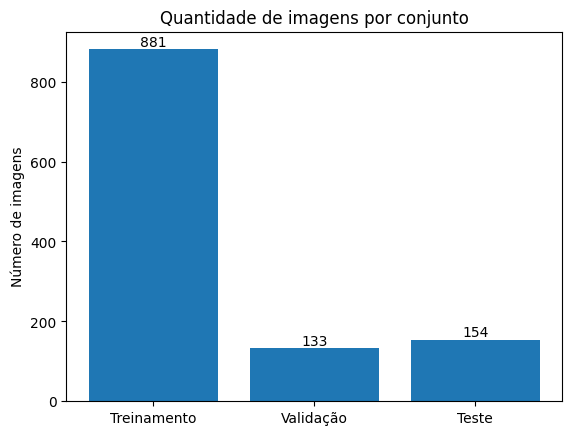

In [15]:
# Gráfico
conjuntos = ["Treinamento", "Validação", "Teste"]
quantidades = [train, validation, test]

ax = plt.bar(conjuntos, quantidades)

plt.title("Quantidade de imagens por conjunto")
plt.ylabel("Número de imagens")

for barra in ax:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura,
        str(int(altura)),
        ha='center',
        va='bottom'
    )

plt.show()

### Integridade dos Arquivos

In [16]:
from PIL import Image
count_corrupted = 0
corrupted = list()

In [17]:
dataframe_list = list()
# 'count_corrupted' and 'corrupted' are initialized in a previous cell

for dataset_folder_name in os.listdir(root_dir):
  dataset_folder_path = os.path.join(root_dir, dataset_folder_name)

  # Ensure it's a directory (e.g., 'train', 'test', 'val') and not a file like 'val.csv' or 'classname.txt'
  if os.path.isdir(dataset_folder_path):
    for class_name_folder in os.listdir(dataset_folder_path):
      class_folder_path = os.path.join(dataset_folder_path, class_name_folder)

      # Ensure it's a directory (e.g., 'healthy', 'angular_leaf_spot', 'bean_rust')
      if os.path.isdir(class_folder_path):
        for image_filename in os.listdir(class_folder_path):
          img_path = os.path.join(class_folder_path, image_filename)

          # Ensure it's an actual file and has a dot for extension splitting
          if os.path.isfile(img_path) and '.' in image_filename:
            _, image_format = image_filename.rsplit('.', 1)
            image_format = image_format.lower()
            img = cv2.imread(img_path)

            if img is not None:
              img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
              # Converter a imagem OpenCV para uma imagem do Pillow
              img_pil = Image.fromarray(img_rgb)

              # Gerar o hash da imagem (usando perceptual hash como exemplo)
              img_hash = imagehash.phash(img_pil)
              width, height, channels = img.shape
              img_corrupted = False
            else:
              count_corrupted += 1
              corrupted.append(img_path)
              img_corrupted = True
              img_hash, image_format, width, height, channels = None, None, None, None, None

            # The 'class_name_folder' is the label for the image
            dataframe_list.append([img_path, img_corrupted, img_hash, image_format, width, height, channels, class_name_folder])

In [18]:
print(f"Total de imagens corrompidas: {count_corrupted}")

if count_corrupted > 0:
    print("\nLista de imagens corrompidas:")
    for img in corrupted:
        print(img)
else:
    print("Nenhuma imagem corrompida foi encontrada.")

Total de imagens corrompidas: 1

Lista de imagens corrompidas:
./bean-leaf-lesions-classification/train/healthy/healthy_train.120tore


In [19]:
print(corrupted)
print(len(corrupted))

['./bean-leaf-lesions-classification/train/healthy/healthy_train.120tore']
1


In [20]:
if corrupted:
    if os.path.exists(corrupted[0]):
        os.remove(corrupted[0])
    else:
        print(f"O arquivo {corrupted[0]} não foi encontrado. Pode já ter sido removido ou não existe.")
else:
    print("Nenhum arquivo corrompido para remover.")

In [21]:
if corrupted:
    print(os.path.exists(corrupted[0]))
else:
    print("Nenhum arquivo corrompido na lista para verificar existência.")

False


In [22]:
df = pd.DataFrame(columns=['image_path', 'corrupted', 'image_hash', 'image_format', 'width', 'height', 'channels', 'label'], data = dataframe_list)

In [23]:
df.head()

,image_path,corrupted,image_hash,image_format,width,height,channels,label
0,./bean-leaf-lesions-classification/train/angul...,False,d7c5704b3f152839,jpg,500.0,500.0,3.0,angular_leaf_spot
1,./bean-leaf-lesions-classification/train/angul...,False,95d05a2fb86ce1aa,jpg,500.0,500.0,3.0,angular_leaf_spot
2,./bean-leaf-lesions-classification/train/angul...,False,d591781a217f0be5,jpg,500.0,500.0,3.0,angular_leaf_spot
3,./bean-leaf-lesions-classification/train/angul...,False,954d7947636a6a62,jpg,500.0,500.0,3.0,angular_leaf_spot
4,./bean-leaf-lesions-classification/train/angul...,False,851d6767a47bb230,jpg,500.0,500.0,3.0,angular_leaf_spot


#### Verificar se todas as imagens estão no mesmo formato

In [24]:
import os
from collections import Counter

root = "./bean-leaf-lesions-classification"

formatos = []

# Percorre todas as pastas do dataset
for conjunto in ["train", "val", "test"]:
    pasta_conjunto = os.path.join(root, conjunto)

    for classe in os.listdir(pasta_conjunto):
        pasta_classe = os.path.join(pasta_conjunto, classe)

        if not os.path.isdir(pasta_classe):
            continue

        for arquivo in os.listdir(pasta_classe):
            extensao = os.path.splitext(arquivo)[1].lower()
            formatos.append(extensao)

# Conta quantos arquivos existem de cada formato
contagem = Counter(formatos)

print("Formatos encontrados:")
for formato, quantidade in contagem.items():
    print(f"{formato}: {quantidade} imagens")

Formatos encontrados:
.jpg: 1167 imagens


In [25]:
# Tipos de imagens
pastas = {
    "Treinamento": "./bean-leaf-lesions-classification/train",
    "Validação": "./bean-leaf-lesions-classification/val",
    "Teste": "./bean-leaf-lesions-classification/test"
}

for nome_pasta, diretorio in pastas.items():

    formatos = {}

    for classe in os.listdir(diretorio):
        pasta_classe = os.path.join(diretorio, classe)

        if os.path.isdir(pasta_classe):
            for arquivo in os.listdir(pasta_classe):
                extensao = os.path.splitext(arquivo)[1].lower()

                if extensao in formatos:
                    formatos[extensao] += 1
                else:
                    formatos[extensao] = 1

    print(f"\n=== {nome_pasta} ===")
    for formato, quantidade in formatos.items():
        print(f"{formato}: {quantidade} imagens")


=== Treinamento ===
.jpg: 880 imagens

=== Validação ===
.jpg: 133 imagens

=== Teste ===
.jpg: 154 imagens


##### Resumo:


Foi encontrado o arquivo 'healthy_train.120tore' como corrompido e foi excluído.

Foi avaliada a estrutura do dataset

Foi realizada a separação de 15% das imagens de treinamento para teste.

Portanto ficaram 880 imagens para treinamento, 133 imagens de validação e 154 imagens para teste.

Gerado o gráfico.

Verificado se todas as imagens estão no mesmo formato


### Consistência dos Metadados

In [26]:
#Informações estatísticas dos valores de altura, largura e canais das imagens

df.describe().loc[['mean', 'std', 'min', 'max']]

,width,height,channels
mean,500.0,500.0,3.0
std,0.0,0.0,0.0
min,500.0,500.0,3.0
max,500.0,500.0,3.0


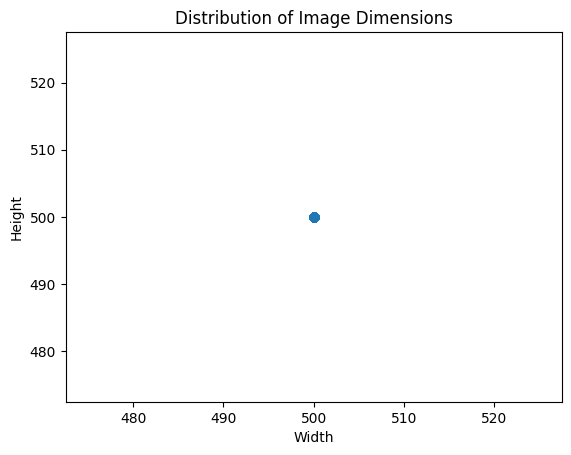

In [27]:
#Distribuição das Dimensões de Altura e Largura das Imagens

plt.scatter(df['width'], df['height'])
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Distribution of Image Dimensions')
plt.show()

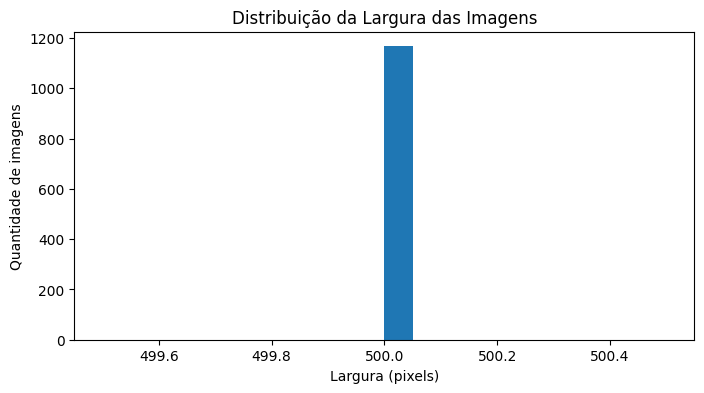

In [28]:
# Histograma da Largura
plt.figure(figsize=(8,4))
plt.hist(df['width'], bins=20)
plt.xlabel('Largura (pixels)')
plt.ylabel('Quantidade de imagens')
plt.title('Distribuição da Largura das Imagens')
plt.show()

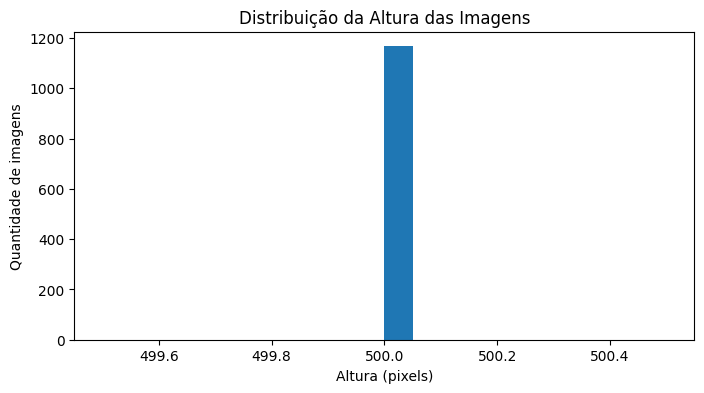

In [29]:
# Histograma da altura
plt.figure(figsize=(8,4))
plt.hist(df['height'], bins=20)
plt.xlabel('Altura (pixels)')
plt.ylabel('Quantidade de imagens')
plt.title('Distribuição da Altura das Imagens')
plt.show()

In [30]:
dimensoes = (
    df.groupby(['width', 'height'])
      .size()
      .reset_index(name='quantidade')
)

print(dimensoes)

   width  height  quantidade
0  500.0   500.0        1167


In [31]:
print(df.columns)

Index(['image_path', 'corrupted', 'image_hash', 'image_format', 'width',
       'height', 'channels', 'label'],
      dtype='object')


In [32]:
#Quantidade de informações nulas
df.isnull().sum()

,0
image_path,0
corrupted,0
image_hash,1
image_format,1
width,1
height,1
channels,1
label,0


### Qualidade das Imagens

In [33]:
#Total de imagens corrompidas

df['corrupted'].sum()

np.int64(1)

In [34]:
#Quantidade de imagens corrompidas e não corrompidas

df['corrupted'].value_counts()

,count
corrupted,
False,1167
True,1


### Distribuição das Classes

In [35]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]

In [36]:
from pathlib import Path
import pandas as pd

# Caminho apontando para a pasta que você mostrou na imagem
pastas = {
    "Treinamento": "./bean-leaf-lesions-classification/train",
    "Validação": "./bean-leaf-lesions-classification/val",
    "Teste": "./bean-leaf-lesions-classification/test"
}


# Extensões de imagem comuns
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

data = []

# Varre todos os arquivos dentro da pasta archive
for split_name, folder_path_str in pastas.items():
    folder_path = Path(folder_path_str)
    for file_path in folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            # Captura o caminho relativo a partir do diretório base (por exemplo, train, val, test)
            # A estrutura esperada agora é: base_folder/classe/imagem.jpg
            relative_to_base = file_path.relative_to(folder_path)

            # A label é o nome da pasta da classe
            label = relative_to_base.parent.name

            data.append({"Split": split_name, "Classe": label})

# Criar o DataFrame principal
df_images = pd.DataFrame(data)

if df_images.empty:
    print("Nenhuma imagem encontrada. Verifique os caminhos e a estrutura das pastas.")
else:
    print(f"Total de imagens encontradas: {len(df_images)}")

Total de imagens encontradas: 1167


In [37]:
# Agrupa por classe e split (se houver) para contar
if df_images['Split'].nunique() > 1:
    df_dist = df_images.groupby(['Split', 'Classe']).size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist.groupby('Split')['Quantidade'].transform('sum')) * 100
else:
    df_dist = df_images.groupby('Classe').size().reset_index(name='Quantidade')
    df_dist['Porcentagem (%)'] = (df_dist['Quantidade'] / df_dist['Quantidade'].sum()) * 100

# Exibir a tabela formatada
print("\n         Tabela de Distribuição de Classes")
print(df_dist.to_string(index=False, formatters={'Porcentagem (%)': '{:.2f}%'.format}))


         Tabela de Distribuição de Classes
      Split            Classe  Quantidade Porcentagem (%)
      Teste angular_leaf_spot          52          33.77%
      Teste         bean_rust          50          32.47%
      Teste           healthy          52          33.77%
Treinamento angular_leaf_spot         293          33.30%
Treinamento         bean_rust         298          33.86%
Treinamento           healthy         289          32.84%
  Validação angular_leaf_spot          44          33.08%
  Validação         bean_rust          45          33.83%
  Validação           healthy          44          33.08%


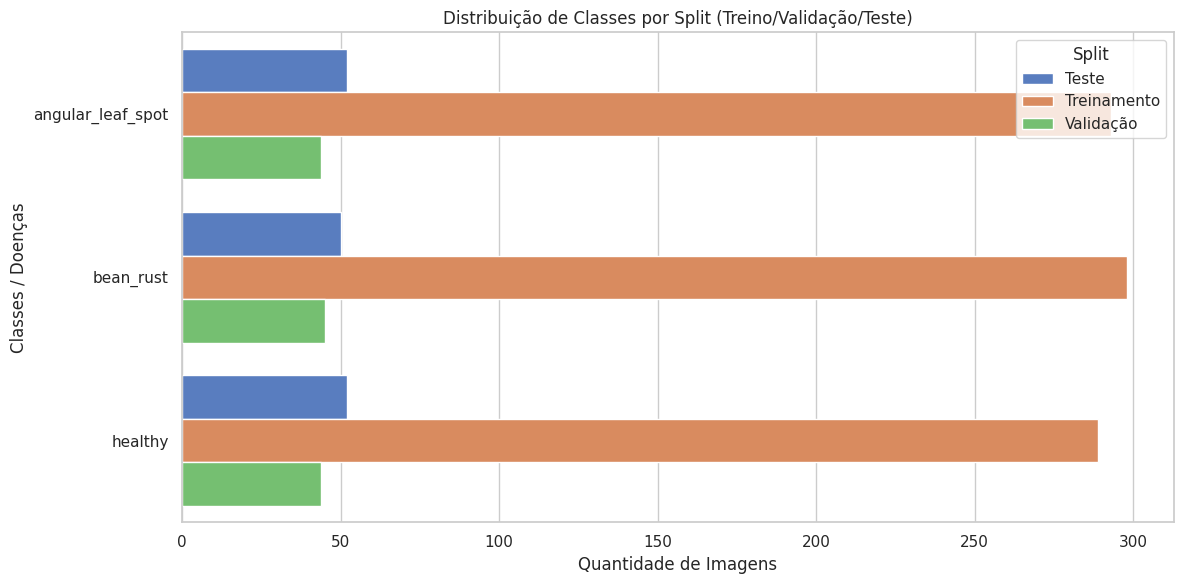

In [38]:
# Plotar o gráfico dependendo da estrutura encontrada
plt.figure(figsize=(12, 6))

if df_images['Split'].nunique() > 1:
    # Gráfico comparativo se houver divisões de treino/validação/teste
    sns.barplot(x='Quantidade', y='Classe', hue='Split', data=df_dist, palette='muted')
    plt.title('Distribuição de Classes por Split (Treino/Validação/Teste)')
else:
    # Gráfico simples
    sns.barplot(x='Quantidade', y='Classe', data=df_dist.sort_values('Quantidade', ascending=False), palette='viridis')
    plt.title('Distribuição Geral de Classes - Lesões de Folhas de Feijão')

plt.xlabel('Quantidade de Imagens')
plt.ylabel('Classes / Doenças')
plt.tight_layout()
plt.show()

## Insights

- As três classes (angular_leaf_spot, bean_rust e healthy) estão distribuídas de forma praticamente idêntica, representando aproximadamente entre 31% e 34% do dataset cada uma. Não é preciso se preocupar com o balanceamento de dados, o modelo tem a quantidade de exemplos necessária para saber o que é uma folha saudável e o que é cada tipo de doença.

-  A Acurácia nesse projeto vai ser uma métrica extremamente confiável devido a natureza balanceada apresentada nesse dataset.



# Resumo

## O que o código faz (Passo a Passo):
- Configuração do Ambiente: Importa as bibliotecas necessárias para manipulação de arquivos (pathlib), modelagem de dados (pandas) e plotagem gráfica (matplotlib e seaborn), definindo um tema visual padronizado.

- Mapeamento Dinâmico de Arquivos: Varre a pasta alvo (archive) filtrando apenas extensões de imagem válidas (.jpg, .jpeg, .png, .bmp). Ele analisa a estrutura de pastas para extrair automaticamente o Split (Treino/Validação/Teste) e a Classe (tipo de doença ou folha saudável), organizando tudo em um DataFrame do Pandas.

- Análise Estatística da Distribuição: Agrupa os dados para calcular a quantidade absoluta de imagens e a porcentagem que cada classe representa dentro de seu respectivo split, exibindo uma tabela formatada no console.

- Visualização Gráfica: Gera um gráfico de barras horizontal comparativo utilizando o seaborn. O gráfico ilustra visualmente a distribuição das classes por split, facilitando a verificação de um possível desbalanceamento de dados.

### Duplicatas

In [39]:
import hashlib
import os
from pathlib import Path
import pandas as pd

# Caminho apontando para a pasta que você mostrou na imagem
pastas = {
     "./bean-leaf-lesions-classification"
    }


In [40]:
# Buscar arquivos CSV ou JSON no diretório
metadata_files = []
for path_str in pastas:
    folder_path = Path(path_str)
    metadata_files.extend(list(folder_path.rglob("*.csv")))
    metadata_files.extend(list(folder_path.rglob("*.json")))

if metadata_files:
    print(f" Encontrado(s) {len(metadata_files)} arquivo(s) de metadados:")
    for meta_path in metadata_files:
        print(f"\n--- Analisando: {meta_path.name} ---")
        if meta_path.suffix == '.csv':
            df_meta = pd.read_csv(meta_path)
        else:
            df_meta = pd.read_json(meta_path)

        # Total de linhas vs Linhas únicas
        total_rows = len(df_meta)
        duplicated_rows = df_meta.duplicated().sum()

        print(f"Total de registros: {total_rows}")
        print(f"Linhas exatamente duplicadas: {duplicated_rows}")

        if duplicated_rows > 0:
            print(" Exemplo de linhas duplicadas:")
            print(df_meta[df_meta.duplicated(keep=False)].head())
else:
    print(" Nenhum arquivo CSV/JSON de metadados encontrado na pasta. Prosseguindo para a verificação das imagens...")

 Encontrado(s) 2 arquivo(s) de metadados:

--- Analisando: val.csv ---
Total de registros: 133
Linhas exatamente duplicadas: 0

--- Analisando: train.csv ---
Total de registros: 1034
Linhas exatamente duplicadas: 0


In [41]:
def calculate_md5(file_path, chunk_size=8192):
    """Calcula o hash MD5 de um arquivo lendo em partes (eficiente em memória)."""
    hasher = hashlib.md5()
    with open(file_path, 'rb') as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)
    return hasher.hexdigest()
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}
image_records = []

print(" Mapeando e gerando hashes de todas as imagens...")

for path_str in pastas:
    base_folder_path = Path(path_str)
    for file_path in base_folder_path.rglob("*"):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            # Determine the relative path to extract split and label
            # We need to reconstruct the relative path from the *first* folder after the base_folder_path
            # For example, if base_folder_path is 'train' and file_path is 'train/healthy/image.jpg'
            # relative_parts should start from 'healthy'

            relative_to_base = file_path.relative_to(base_folder_path)
            parts = relative_to_base.parts

            # Assuming structure: base_folder_path/classe/imagem.jpg
            # If there's only one part, it means it's directly in the base_folder_path, which is unlikely for class labels
            if len(parts) >= 1:
                label = parts[0] # The first subfolder is typically the class
            else:
                label = "unknown" # Fallback if no class folder is found

            # In this context, 'pastas' holds only training data, so 'split' can be hardcoded or inferred if structure allows.
            # For now, let's assume if it's in 'train', split is 'Treinamento'.
            split = "Treinamento" # Adjust if 'pastas' can contain other splits

            # Generates the MD5 hash of the image content
            file_hash = calculate_md5(file_path)

            image_records.append({
                "filename": file_path.name,
                "path": str(file_path),
                "split": split,
                "classe": label,
                "hash_md5": file_hash
            })

df_hashes = pd.DataFrame(image_records)
print(f" Concluído! {len(df_hashes)} imagens processadas.")

 Mapeando e gerando hashes de todas as imagens...
 Concluído! 1167 imagens processadas.


In [42]:
# Identificar hashes que aparecem mais de uma vez
duplicate_hashes = df_hashes[df_hashes.duplicated(subset=['hash_md5'], keep=False)]

if duplicate_hashes.empty:
    print("NENHUMA DUPLICATA ENCONTRADA! O dataset está 100% limpo quanto a conteúdos idênticos.")
else:
    total_duplicadas = duplicate_hashes['hash_md5'].nunique()
    print(f"Foram encontradas imagens duplicadas associadas a {total_duplicadas} hashes diferentes.\n")

    # 1. Checar se há VAZAMENTO DE DADOS (Data Leakage) entre Train e Val
    leakage_df = duplicate_hashes.groupby('hash_md5')['split'].nunique()
    hashes_vazados = leakage_df[leakage_df > 1].index

    if len(hashes_vazados) > 0:
        print(f"ALERTA CRÍTICO DE DATA LEAKAGE!")
        print(f"Existem {len(hashes_vazados)} imagem(ns) idêntica(s) presentes TANTO no Treino QUANTO na Validação.\n")
        print("Exemplos de imagens com vazamento:")
        display(duplicate_hashes[duplicate_hashes['hash_md5'].isin(hashes_vazados)][['filename', 'split', 'classe', 'hash_md5']].head(10))
    else:
        print("Sem Data Leakage: As duplicatas existem, mas não estão cruzando a fronteira de treino/validação.")

    # 2. Exibir tabela resumo de todas as duplicatas
    print("\n--- Tabela Completa de Arquivos Duplicados ---")
    display(duplicate_hashes.sort_values(by='hash_md5')[['filename', 'split', 'classe', 'hash_md5']])

NENHUMA DUPLICATA ENCONTRADA! O dataset está 100% limpo quanto a conteúdos idênticos.


### Informações complementares
Elaborar uma apresentação para mostrar os resultados.

Apresentar o dataset de forma detalhada.

Verifique quais itens em Informações esperadas podem ser aplicados no dataset.

### ATIVIDADE-04-ETAPA-02

#### Objetivo: Apresentar métodos da literatura e propor ideias para métodos próprios.



### Métodos da literatura

#### Notebooks executados

https://www.kaggle.com/code/akhilchibber/bean-leaf-lesions-classification#The-Dataset

 https://www.kaggle.com/code/marquis03/resnet-18-bean-leaf-lesions-classification

### Métodos próprios

#### Apresentar ideias que podem melhorar os métodos encontrados e testados da literatura.

- O notebook analisado não realizou a separação das imagens para teste, portanto sugerimos a separação de uma parte das imagens de treinamento como melhoria;

- O notebook não realizou a análise exploratória dos dados, portanto, a imagem corrompida não foi excluída do dataset;



#### Ideias para melhorar uma técnica

Otimização de Hiperparâmetros - alterar ou reduzir os hiperparâmetros.

Elaborar uma nova arquitetura mais leve para que o treino e o teste sejam rápidos.

Reduzir número de imagens no treinamento e manter o desempenho.

### Informações complementares

Elaborar uma apresentação para mostrar os métodos da literatura e próprios.

### **COMPARAÇÃO COM O MÉTODO EFFICIENT NET**

#### Transformação e aumento das imagens

Usaremos as transformações (transforms) do PyTorch para realizar o pré-processamento e o aumento (data augmentation) das imagens. Essa etapa é fundamental para que os modelos de deep learning consigam generalizar melhor.

In [43]:
# Data Transformation and Augmentation
import torchvision.transforms as transforms

# Define transformations
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    # Other transformations can be added here
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

#### Criar um Dataset Personalizado



Criamos uma classe de dataset personalizada que estende a classe Dataset do PyTorch. Essa classe será responsável por carregar as imagens e aplicar as transformações.

In [44]:
from torch.utils.data import Dataset
from PIL import Image
import os

class BeanLeafDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.root_dir = root_dir
        self.transform = transform

        # Classes
        self.classes = sorted([
            classe
            for classe in os.listdir(root_dir)
            if os.path.isdir(
                os.path.join(root_dir, classe)
            )
        ])

        # classe -> número
        self.class_to_idx = {
            classe: idx
            for idx, classe in enumerate(self.classes)
        }

        self.images = []

        # Percorrer cada classe
        for classe in self.classes:

            pasta_classe = os.path.join(
                root_dir,
                classe
            )

            for arquivo in os.listdir(pasta_classe):

                caminho = os.path.join(
                    pasta_classe,
                    arquivo
                )

                if os.path.isfile(caminho):

                    self.images.append(
                        (
                            caminho,
                            self.class_to_idx[classe]
                        )
                    )

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        caminho, label = self.images[index]

        imagem = Image.open(
            caminho
        ).convert("RGB")

        if self.transform:
            imagem = self.transform(imagem)

        return imagem, label

In [45]:
from torchvision import transforms

train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_test_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#### Criar os datasets sem CSV

In [46]:
root_dir = "./bean-leaf-lesions-classification"

train_dataset = BeanLeafDataset(
    root_dir=os.path.join(root_dir, "train"),
    transform=train_transform
)

val_dataset = BeanLeafDataset(
    root_dir=os.path.join(root_dir, "val"),
    transform=val_test_transform
)

test_dataset = BeanLeafDataset(
    root_dir=os.path.join(root_dir, "test"),
    transform=val_test_transform
)

#### Confira as classes

In [47]:
print("Classes:", train_dataset.classes)
print("Mapeamento:", train_dataset.class_to_idx)

Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Mapeamento: {'angular_leaf_spot': 0, 'bean_rust': 1, 'healthy': 2}


#### Criar DataLoaders



Por fim, configuramos os DataLoaders do PyTorch para os conjuntos de dados de treinamento e validação. Os DataLoaders permitem o carregamento eficiente dos dados e sua divisão em lotes (batches) durante o treinamento.

In [48]:
from torch.utils.data import DataLoader

BATCH_SIZE = 25

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

#### Conferir antes de treinar

In [49]:
print("Treinamento:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))

Treinamento: 880
Validação: 133
Teste: 154


In [50]:
images, labels = next(iter(train_loader))

print("Formato das imagens:", images.shape)
print("Formato dos labels:", labels.shape)
print("Labels:", labels[:10])

Formato das imagens: torch.Size([25, 3, 224, 224])
Formato dos labels: torch.Size([25])
Labels: tensor([0, 1, 0, 1, 1, 1, 1, 2, 0, 0])


#### Checagem

In [51]:
print("Classes:", train_dataset.classes)
print("Mapeamento:", train_dataset.class_to_idx)

print("Treinamento:", len(train_dataset))
print("Validação:", len(val_dataset))
print("Teste:", len(test_dataset))

Classes: ['angular_leaf_spot', 'bean_rust', 'healthy']
Mapeamento: {'angular_leaf_spot': 0, 'bean_rust': 1, 'healthy': 2}
Treinamento: 880
Validação: 133
Teste: 154


Isso conclui a etapa de Preparação dos Dados. Em seguida, passaremos para a etapa de construção do modelo.

#### Construção do Modelo



Nesta seção, vamos nos concentrar na configuração do modelo de deep learning. Ela abordará a parte do script em que o modelo de rede neural é carregado, utilizando os modelos pré-treinados do PyTorch, e posteriormente modificado para a tarefa específica de classificação.

Isso inclui a criação da classe MyDataset e a modificação da camada classificadora do modelo.

#### Importar as Bibliotecas Necessárias


Primeiro, precisamos importar os componentes necessários do PyTorch.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

#### Definir o Modelo

Usaremos um modelo pré-treinado e modificaremos sua camada final para adequá-lo à nossa tarefa de classificação, que possui três classes:

healthy — saudável

angular_leaf_spot — mancha-angular da folha

bean_rust — ferrugem do feijoeiro

In [ ]:
# Define the number of classes
num_classes = 3

# Load a pre-trained model
model = models.efficientnet_v2_s(pretrained=True)

# Modify the classifier
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

# Print the Deep Learning model architecture
print(model)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_V2_S_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): FusedMBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (1): BatchNorm2d(24, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  

#### Definir o Dispositivo

Precisamos definir o dispositivo como CPU ou GPU (caso esteja disponível) para realizar o treinamento do modelo.

In [ ]:
# Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move the model to the chosen device
model = model.to(device)

#### Imprimir o Resumo do Modelo


In [ ]:
pip install torchsummary

In [ ]:
from torchsummary import summary

# Imprimir o resumo do modelo 3, 224, 224
summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 24, 112, 112]             648
       BatchNorm2d-2         [-1, 24, 112, 112]              48
              SiLU-3         [-1, 24, 112, 112]               0
            Conv2d-4         [-1, 24, 112, 112]           5,184
       BatchNorm2d-5         [-1, 24, 112, 112]              48
              SiLU-6         [-1, 24, 112, 112]               0
   StochasticDepth-7         [-1, 24, 112, 112]               0
       FusedMBConv-8         [-1, 24, 112, 112]               0
            Conv2d-9         [-1, 24, 112, 112]           5,184
      BatchNorm2d-10         [-1, 24, 112, 112]              48
             SiLU-11         [-1, 24, 112, 112]               0
  StochasticDepth-12         [-1, 24, 112, 112]               0
      FusedMBConv-13         [-1, 24, 112, 112]               0
           Conv2d-14           [-1, 96,

Isso conclui a etapa de construção do modelo. Carregamos com sucesso um modelo EfficientNet pré-treinado e o adaptamos para nossa tarefa de classificação em três classes.

O modelo agora está pronto para ser treinado com o nosso conjunto de dados de lesões em folhas de feijão.

#### **Treinamento e Validação do Modelo**

Esta etapa abrangerá o loop de treinamento e as funções necessárias para o treinamento (train) e a validação (val).

Serão detalhadas as etapas do processo de treinamento, incluindo a configuração da função de perda (loss function), do otimizador (optimizer), do agendador da taxa de aprendizado (learning rate scheduler) e do próprio loop de treinamento, que inclui o mecanismo de early stopping (parada antecipada).

#### Importar as Bibliotecas Necessárias

Primeiro, precisamos garantir que todas as bibliotecas necessárias estejam importadas.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from tqdm import tqdm

# Hiperparâmetros de treinamento


In [ ]:
# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer (using AdamW here)
optimizer = optim.AdamW(model.parameters(), lr=0.0001)

# Learning rate scheduler (optional)
lr_scheduler = lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

AttributeError: 'StepLR' object has no attribute 'StepLR'

#### Funções de Treinamento e Validação

Definimos as funções responsáveis pelo treinamento e pela validação do modelo.

In [ ]:
def train_model(model, criterion, optimizer, scheduler, train_loader, val_loader, num_epochs=25):
    train_loss_history = []
    train_acc_history = []
    val_loss_history = []
    val_acc_history = []

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device).long()

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward pass
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Save the metrics as Python numbers
            if phase == 'train':
                train_loss_history.append(epoch_loss)
                train_acc_history.append(epoch_acc.item())  # Convert to Python number
            else:
                val_loss_history.append(epoch_loss)
                val_acc_history.append(epoch_acc.item())  # Convert to Python number

    print('Training complete')

    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history

#### Treinar o Modelo

Agora, utilizamos as funções definidas anteriormente para treinar e validar o nosso modelo. Definimos o número de épocas (epochs) de acordo com a necessidade do treinamento.

In [ ]:
model, train_loss_history, train_acc_history, val_loss_history, val_acc_history = train_model(model, criterion, optimizer, lr_scheduler, train_loader, val_loader, num_epochs=25)

Epoch 1/25
----------


FileNotFoundError: [Errno 2] No such file or directory: './bean-leaf-lesions-classification/train/angular_leaf_spot/angular_leaf_spot_train.194.jpg'

# Matriz de confusão

Explicação: Este código avalia um modelo de classificação em um conjunto de teste, armazenando rótulos verdadeiros e previsões. Ele gera um relatório de classificação e visualiza a matriz de confusão, mostrando o desempenho do modelo em termos de acurácia e outras métricas.

# Inspeção Visual

Explicação: O código à seguir visualiza as previsões de um modelo em um conjunto de teste, mostrando 9 imagens em uma grade. Cada imagem é acompanhada de sua previsão, a probabilidade da previsão e o rótulo verdadeiro. Isso ajuda a entender como o modelo está se comportando em relação às classes reais.

**Vamos entender cada parte:**

**from sklearn.preprocessing import LabelEncoder:** Isso importa uma ferramenta chamada LabelEncoder. Pense nela como um dicionário que traduz os nomes das suas doenças ('angular_leaf_spot', 'bean_rust', 'healthy') para números (0, 1, 2) e vice-versa. O computador trabalha melhor com números, mas nós entendemos melhor os nomes.

**le = LabelEncoder() e le.fit(classes):** Aqui, criamos esse 'dicionário' (le) e 'ensinamos' a ele quais são todas as categorias de doenças (classes) que o modelo pode prever.

**preds = y_pred, truth = y_true, probas = y_prob:** Essas linhas estão apenas pegando os resultados que o modelo calculou na célula anterior:

**y_pred:** O que o modelo previu para cada imagem de teste (em números).
**y_true:** O que é a verdade sobre cada imagem de teste (a doença real, também em números).
**y_prob:** A confiança que o modelo teve em cada previsão (um número entre 0 e 1, onde 1 significa 100% de certeza).
**pred_labels = le.inverse_transform(np.array(preds)) e truth_labels = le.inverse_transform(np.array(truth)):** Agora, usamos nosso 'dicionário' (le) para converter as previsões e as verdades que estavam em números de volta para os nomes das doenças, para que possamos entender. pred_labels terá os nomes previstos e truth_labels os nomes reais.

**index = 0 e fig, axes = plt.subplots(...):** Preparamos o palco para mostrar as imagens. plt.subplots cria uma grade, neste caso, de 3 linhas e 3 colunas (total de 9 espaços para imagens).

**for i in range(3): for j in range(3)::** Este é um loop que passa por cada um dos 9 espaços na grade para mostrar uma imagem por vez.

**image_path = test_dataset.data[index][0]:** Pega o caminho do arquivo da imagem de teste atual.
**axes[i][j].imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)):** Lê a imagem do disco, ajusta suas cores para o formato correto e a exibe no espaço atual da grade.
**axes[i][j].set_title(...):** Coloca um título em cima de cada imagem, informando:
**Pred: {pred_labels[index]}:** Qual foi a previsão do modelo para aquela imagem (por exemplo, "Pred: healthy").
**{round(probas[index]*100, 2)}%:** Qual a porcentagem de confiança do modelo nessa previsão (por exemplo, "99.50%").
Actual: {truth_labels[index]}: Qual é a verdade (a doença real) daquela imagem (por exemplo, "Actual: healthy").
index += 1: Avança para a próxima imagem de teste.
plt.tight_layout() e plt.show(): Ajusta o layout para que os títulos e imagens não se sobreponham e, finalmente, mostra a grade de imagens.

**Como avaliar o resultado:**
Ao olhar para essa grade de imagens, você deve se perguntar:

O modelo acertou? Compare a linha "Pred" com a linha "Actual". Se forem iguais, o modelo acertou! Se forem diferentes, ele errou.
Quão confiante ele estava? Olhe para a porcentagem ao lado da previsão.
Acertos com alta confiança (ex: 95%+): Ótimo! O modelo está seguro e correto.
Acertos com baixa confiança (ex: 55%-70%): O modelo acertou, mas estava um pouco incerto. Pode ser um bom sinal de que a imagem era difícil, ou que o modelo ainda pode melhorar.
Erros com alta confiança (ex: 90%+): Preocupante! O modelo errou feio e estava muito seguro disso. Isso indica que ele pode estar "aprendendo" algo errado ou não distinguindo bem entre certas classes.
Erros com baixa confiança (ex: 50%-60%): O modelo errou, mas sabia que estava incerto. É melhor do que errar com alta confiança, mas ainda é um erro.
Ao inspecionar visualmente essas 9 imagens, você pode ter uma ideia intuitiva de quais tipos de erros o modelo está cometendo e se as imagens em que ele erra são particularmente desafiadoras até mesmo para um humano.

### Outras formas de inspeção visual:

1.  **Inspeção de exemplos mal classificados (Erros do Modelo):** Em vez de apenas ver 9 exemplos aleatórios, podemos focar nas imagens que o modelo **errou**. Isso é fundamental para entender onde ele está falhando. Podemos plotar as imagens em que o `Pred` e o `Actual` são diferentes, para ver padrões de erro.

2.  **Análise de Confiança do Modelo:** Além da classe que o modelo previu, é importante ver o quão *confiante* ele estava. Se ele acertou, mas estava pouco confiante (ex: 55%), isso pode indicar uma imagem difícil ou um limite de decisão. Se ele errou, mas estava muito confiante (ex: 98%), isso é mais preocupante, pois o modelo está 'enganado' com convicção.

3.  **Mapas de Ativação de Classe (CAMs ou Grad-CAMs):** São técnicas mais avançadas que mostram **quais partes da imagem o modelo está olhando** para tomar a decisão. Por exemplo, se o modelo classifica uma folha como 'doente' porque está olhando para o cabo ou para o fundo da imagem em vez da mancha, isso é um grande problema! Esses mapas geram uma espécie de 'mapa de calor' sobre a imagem, destacando as regiões mais importantes para a previsão do modelo. Isso é excelente para diagnosticar se o modelo está 'colando' em características irrelevantes.

### O modelo pode dar um resultado ótimo e na verdade ele está errando? Como corrigir?

**Sim, absolutamente!** As métricas (como acurácia, precisão, recall, etc.) são resumos numéricos do desempenho, mas elas podem enganar em certas situações. Aqui estão os principais motivos e como corrigir:

1.  **Overfitting (Superajuste):**
    *   **O que é:** O modelo 'decorou' os dados de treinamento e validação tão bem que não consegue generalizar para novas imagens que nunca viu antes (o mundo real). As métricas no conjunto de treinamento e validação podem ser altíssimas, mas no uso prático, ele falha.
    *   **Como identificar:** Observe o gráfico de acurácia que você gerou: se a acurácia de treino continua subindo e a de validação começa a cair ou estagnar, é um forte sinal de overfitting.
    *   **Como corrigir:**
        *   **Mais dados:** Aumentar a quantidade e diversidade dos dados de treinamento ajuda o modelo a aprender padrões mais gerais.
        *   **Aumento de Dados (Data Augmentation):** Criar variações das imagens existentes (rotacionar, espelhar, cortar, mudar brilho, etc.). Você já está usando algumas dessas transformações (`RandomHorizontalFlip`, `RandomRotation`), o que é ótimo!
        *   **Regularização:** Adicionar penalidades para que o modelo não se torne complexo demais (por exemplo, `dropout` em camadas do modelo ou regularização L1/L2).
        *   **Modelos mais simples:** Às vezes, um modelo menos complexo é melhor se os dados não forem suficientes para um modelo muito grande (mas no seu caso, ResNet50 é um modelo pré-treinado robusto).
        *   **Parada Antecipada:** Interromper o treinamento quando a acurácia de validação começa a piorar, mesmo que a de treinamento ainda esteja melhorando.

2.  **Conjunto de Teste Não Representativo:**
    *   **O que é:** O conjunto de teste (as 154 imagens) pode ser muito parecido com o conjunto de treinamento, ou não contém a diversidade de imagens que o modelo vai encontrar no mundo real. Assim, o modelo se sai bem no teste, mas mal na prática.
    *   **Como identificar:** Se o modelo falha consistentemente em cenários específicos do mundo real que não estavam no teste.
    *   **Como corrigir:** Garantir que o conjunto de teste seja o mais variado e representativo possível dos dados que o modelo encontrará na vida real. Coletar mais dados de teste de fontes diferentes.

3.  **Viés nos Dados (Data Bias):**
    *   **O que é:** Se o conjunto de dados tem um viés (por exemplo, todas as fotos de folhas saudáveis foram tiradas em uma condição de luz específica, e as folhas doentes em outra), o modelo pode aprender a prever 'saudável' baseado na condição de luz, e não na doença em si. Ele vai parecer bom nas métricas, mas falhará em condições diferentes.
    *   **Como identificar:** Inspeção visual com CAMs (para ver se o modelo olha para o que deveria) e análise de erros, procurando padrões nos cenários onde o modelo erra.
    *   **Como corrigir:** Balancear os dados para remover o viés, se possível. Coletar dados mais diversificados. Usar técnicas de aumento de dados que variem mais as condições (ex: `RandomBrightness`, `ColorJitter`).

4.  **Métrica de Avaliação Inadequada:**
    *   **O que é:** A acurácia pode ser uma boa métrica para conjuntos de dados balanceados, mas em casos de desbalanceamento severo (ex: 99% das imagens são 'saudáveis' e 1% 'doentes'), um modelo que sempre prevê 'saudável' teria 99% de acurácia, mas seria inútil! Você já verificou o balanceamento do seu dataset, e ele está bem balanceado, o que é ótimo para a acurácia.
    *   **Como corrigir:** Usar outras métricas como `F1-score`, `precisão` e `recall`, que você já gerou no relatório de classificação. Elas dão uma visão mais completa do desempenho, especialmente para cada classe. Por exemplo:
        *   **Precisão (Precision):** Das vezes que o modelo disse que algo era 'doente', quantas vezes ele realmente acertou?
        *   **Recall:** De todas as folhas que *realmente* estavam 'doentes', quantas o modelo conseguiu identificar?

### Próximos Passos para Aprofundar a Inspeção:

Para o seu caso, eu sugeriria:

1.  **Plotar os exemplos mal classificados do conjunto de teste:** Crie uma célula de código para exibir especificamente as imagens onde `y_pred` é diferente de `y_true`. Isso vai te dar insights valiosos sobre os tipos de erros que o modelo comete.

2.  **Investigar a confiança em erros:** Para esses exemplos mal classificados, observe a `probas` para entender o nível de certeza do modelo ao errar.

Essas análises mais profundas vão te ajudar a entender a 'personalidade' do seu modelo e onde ele precisa de mais treinamento ou ajustes.

### Visualização de Exemplos Mal Classificados

### Conclusões